In [12]:
import numpy as np

In [1]:
import torch

In [2]:
print(torch.__version__)

2.7.1


# Try a Fully Connected Network

In [9]:
class FullyConnected(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.gelu = torch.nn.GELU()
        self.fc1 =  torch.nn.Linear(input_size, hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size, hidden_size)
        self.fc3 = torch.nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
        x = self.fc1(x)
        x = self.gelu(x)
        x = self.fc2(x)
        x = self.gelu(x)
        x = self.fc3(x)
        return x

In [10]:
# Model parameter settings
input_size = 10
hidden_size = 20
output_size = 2 # binary classification

# Model initialization
model = FullyConnected(input_size, hidden_size, output_size)

# Training loop parameters
num_epochs = 100
batch_size = 32
learning_rate = 0.001

# Loss function and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [ ]:
# dataset and dataloader
X_numpy = np.random.randn(500, input_size)
X = torch.from_numpy(X_numpy).float()

y_numpy = np.random.randint(0, output_size, (500,))
y = torch.from_numpy(y_numpy).long()

dataset = torch.utils.data.TensorDataset(X, y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)



In [16]:
# Training loop
for epoch in range(num_epochs):
    running_loss = 0.0

    for inputs, labels in dataloader:
        #  Zero the parameter gradients
        optimizer.zero_grad()

        loss = criterion(model(inputs), labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(dataloader):.4f}')

print('Training finished!')
# Test the model


Epoch [10/100], Loss: 0.6800
Epoch [20/100], Loss: 0.6645
Epoch [30/100], Loss: 0.6450
Epoch [40/100], Loss: 0.6235
Epoch [50/100], Loss: 0.6016
Epoch [60/100], Loss: 0.5781
Epoch [70/100], Loss: 0.5584
Epoch [80/100], Loss: 0.5464
Epoch [90/100], Loss: 0.5295
Epoch [100/100], Loss: 0.5114
Training finished!


In [19]:
# Inference
X_test_numpy = np.random.randn(10, input_size)
y_test_numpy = np.random.randint(0, output_size, (10,))
X_test = torch.from_numpy(X_test_numpy).float()

with torch.no_grad():
    outputs = model(X_test)
    _, X_predicted = torch.max(outputs.data, 1)
    print(f'Predictions: {X_predicted}')
    

Predictions: tensor([1, 0, 0, 1, 0, 1, 1, 1, 0, 0])


In [22]:
X_preticted_numpy = X_predicted.numpy()

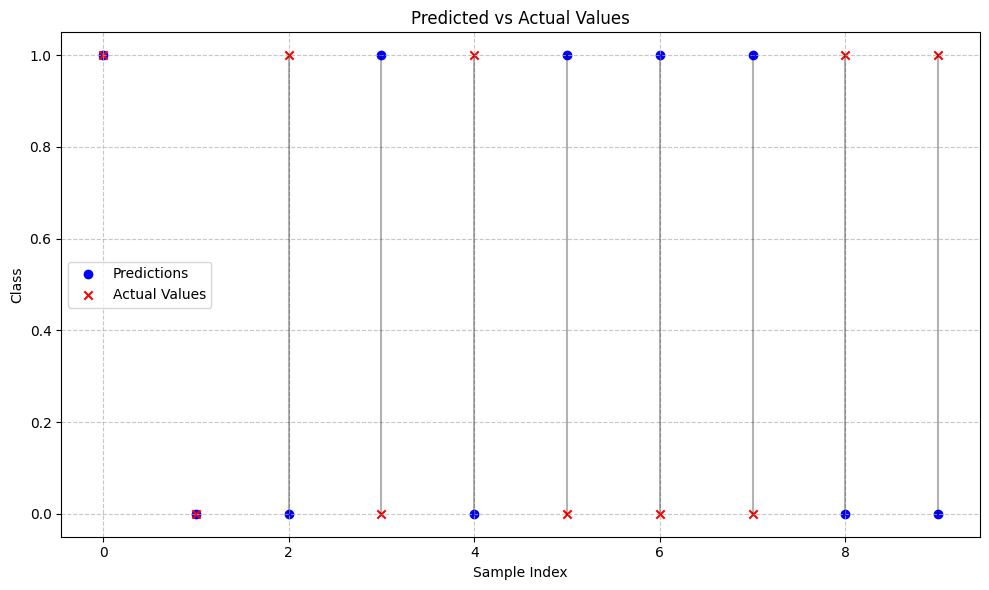

Accuracy: 20.00%


In [23]:
# Visualize predictions vs actual values
import matplotlib.pyplot as plt

# Create a figure and axis
plt.figure(figsize=(10, 6))

# Create indices for the x-axis
indices = np.arange(len(X_preticted_numpy))

# Plot the predicted and actual values
plt.scatter(indices, X_preticted_numpy, color='blue', label='Predictions', marker='o')
plt.scatter(indices, y_test_numpy, color='red', label='Actual Values', marker='x')

# Connect predictions to actual values with lines to show differences
for i in range(len(indices)):
    plt.plot([indices[i], indices[i]], [X_preticted_numpy[i], y_test_numpy[i]], 'k-', alpha=0.3)

# Add labels and title
plt.xlabel('Sample Index')
plt.ylabel('Class')
plt.title('Predicted vs Actual Values')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

# Calculate and display accuracy
accuracy = np.mean(X_preticted_numpy == y_test_numpy) * 100
print(f'Accuracy: {accuracy:.2f}%')


# Basic Multi-head Attention

In [37]:
# Initialize the sentence
sentence = "Larry, you need to get a job in large language modeling."
dc = {word:integer for integer, word in enumerate(sorted(sentence.replace(",","").split()))}
sentence_int = torch.tensor([dc[word] for word in sentence.replace(",","").split()])

In [38]:
sentence_int

tensor([ 0, 10,  8,  9,  2,  1,  4,  3,  6,  5,  7])

In [145]:
# Word Embedding
vocab_size = 50000
embedding_dim = 48 # embedding dimension = num_heads * d_v
torch.manual_seed(123)

In [146]:
embedding = torch.nn.Embedding(vocab_size, embedding_dim)

In [147]:
sentence_embedded = embedding(sentence_int).detach() # detach the gradient for embedding

In [148]:
sentence_embedded.size()

torch.Size([11, 48])

In [149]:
sentence_embedded.shape[1] # embedding dimension

48

In [150]:
# Transformer parameters
d_q = 5
d_k = 5
d_v = 6

In [151]:
W_q = torch.nn.Parameter(torch.randn(d_q, embedding_dim))
W_k = torch.nn.Parameter(torch.randn(d_k, embedding_dim))
W_v = torch.nn.Parameter(torch.randn(d_v, embedding_dim))

In [152]:
query = sentence_embedded @ W_q.T
key = sentence_embedded @ W_k.T
value = sentence_embedded @ W_v.T
query.shape, key.shape, value.shape
# Scaled Dot-Product Attention



(torch.Size([11, 5]), torch.Size([11, 5]), torch.Size([11, 6]))

In [153]:
query[0,]

tensor([-8.1809,  0.0804, -6.1531,  7.8766, -6.7471],
       grad_fn=<SelectBackward0>)

In [154]:
omega = query @ key.T

In [155]:
omega

tensor([[  38.0249,   89.8163,   72.5053,   98.5988,   62.8085,  103.2005,
          -37.2008, -107.9493, -249.8309,  254.4420,  192.6119],
        [  88.6360,   81.5151, -262.7095,  139.2739,   57.5123,   -4.9654,
         -129.8188,  -71.3864, -230.3675,   49.5134,   13.6680],
        [  20.9534,   36.3202,  210.4074,   67.1263,   35.3932,  205.5914,
           -0.9904,  -31.9063, -166.5594,  307.9792,  211.7363],
        [  52.3713,   -2.4627,  145.9242,   21.0383,  -70.5052,   87.4416,
          -12.9297,   47.5303, -136.3699,  138.2650,   90.7997],
        [ -52.2060,  -71.0104, -448.3412, -153.9325,  -30.3914, -393.5969,
          -19.0858,   68.8742,  353.6273, -611.5701, -421.5949],
        [ 104.1783, -112.4864, -296.1796,  164.6169, -162.6368,   15.0681,
          -33.9652,  165.3405,  103.9648, -216.7869, -273.1201],
        [  37.9626,   31.3970,  180.6071,  -47.1328,   14.6604,  126.6406,
          -66.0638,   36.9244, -190.1345,  226.9066,  177.8100],
        [ -41.9137, 

In [156]:
query.shape

torch.Size([11, 5])

In [157]:
query_0 = query[0,]

In [158]:
omega_0 = query_0 @ key.T

In [159]:
F.softmax(omega_0 / d_k**0.5, dim = 0)


tensor([9.2626e-43, 1.0617e-32, 4.6114e-36, 5.3923e-31, 6.0324e-38, 4.2219e-30,
        0.0000e+00, 0.0000e+00, 0.0000e+00, 1.0000e+00, 9.7998e-13],
       grad_fn=<SoftmaxBackward0>)

In [160]:
import torch.nn.functional as F

In [161]:
alpha = F.softmax(omega / d_k**0.5, dim = 1)

In [162]:
return_result = alpha @ value

In [163]:
class ScaledDotProductAttention(torch.nn.Module):
    def __init__(self, d_qk, d_v, embedding_dim, num_heads = 1):
        super().__init__()
        self.d_qk = d_qk
        self.W_q = torch.nn.Parameter(torch.randn(d_qk, embedding_dim))
        self.W_k = torch.nn.Parameter(torch.randn(d_qk, embedding_dim))
        self.W_v = torch.nn.Parameter(torch.randn(d_v, embedding_dim))
        
    def forward(self, x):
        # x dimension: batch_size, sequence_length, embedding_dim
        query = x @ self.W_q.T
        key = x @ self.W_k.T
        value = x @ self.W_v.T

        omega = query @ key.T
        alpha = torch.softmax(omega / self.d_qk**0.5, dim = -1)

        # return dimension: batch_size, sequence_length, d_v
        return alpha @ value

In [165]:
single_head_attention = ScaledDotProductAttention(d_q, d_v, embedding_dim)

In [166]:
sentence_embedded.shape

torch.Size([11, 48])

In [167]:
result = single_head_attention(sentence_embedded)

In [168]:
result.shape

torch.Size([11, 6])

In [169]:
single_head_attention_2 = ScaledDotProductAttention(d_q, d_v, embedding_dim)

In [170]:
result_2 = single_head_attention_2(sentence_embedded)

In [171]:
torch.stack([result, result_2], dim=0).shape


torch.Size([2, 11, 6])

In [172]:
torch.cat([result, result_2], dim=-1).shape

torch.Size([11, 12])

In [173]:
class MultiHeadAttention(torch.nn.Module):
    def __init__(self, d_qk, d_v, d_embed, num_heads = 8):
        super().__init__()
        self.heads = torch.nn.ModuleList([ScaledDotProductAttention(d_qk, d_v, d_embed) for 
                                          _ in range(num_heads)])
    
    def forward(self, x):
        output = []
        for head in self.heads:
            output.append(head(x))
        return torch.cat(output, dim=-1)

In [174]:
num_heads = 8
mha = MultiHeadAttention(d_q, d_v, embedding_dim, num_heads)

In [175]:
result = mha(sentence_embedded)

In [176]:
result.shape

torch.Size([11, 48])

In [177]:
class TransformerBlock(torch.nn.Module):
    def __init__(self, d_qk, d_v, d_embed, num_heads=8, d_ff=2048):
        super().__init__()
        self.multi_head_attention = MultiHeadAttention(d_qk, d_v, d_embed, num_heads)
        self.norm1 = torch.nn.LayerNorm(d_embed)
        self.norm2 = torch.nn.LayerNorm(d_embed)
        
        # Feed forward network
        self.feed_forward = torch.nn.Sequential(
            torch.nn.Linear(d_embed, d_ff),
            torch.nn.ReLU(),
            torch.nn.Linear(d_ff, d_embed)
        )
    
    def forward(self, x):
        # Multi-head attention with residual connection and layer norm
        attn_output = self.multi_head_attention(x)
        x = self.norm1(x + attn_output)
        
        # Feed forward with residual connection and layer norm
        ff_output = self.feed_forward(x)
        x = self.norm2(x + ff_output)
        
        return x

class TransformerEncoder(torch.nn.Module):
    def __init__(self, d_qk, d_v, d_embed, num_heads=8, num_layers=6, d_ff=2048):
        super().__init__()
        self.layers = torch.nn.ModuleList([
            TransformerBlock(d_qk, d_v, d_embed, num_heads, d_ff) 
            for _ in range(num_layers)
        ])
    
    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

# Example usage:
# Create a 7-layer transformer encoder
transformer_encoder = TransformerEncoder(d_q, d_v, embedding_dim, num_heads=8, num_layers=7)

# Pass the embedded sentence through all layers
transformer_output = transformer_encoder(sentence_embedded)
print(f"Output shape: {transformer_output.shape}")


Output shape: torch.Size([11, 48])


In [178]:
feed_forward = torch.nn.Sequential(
    torch.nn.Linear(embedding_dim, 2048),
    torch.nn.GELU(),
    torch.nn.Linear(2048, embedding_dim)
)

feed_forward(result)

tensor([[ 3.0753e+00, -2.8351e-01,  1.6292e+00,  8.0786e-01,  1.5224e+00,
         -1.7084e+00,  7.6022e-01,  3.9362e+00, -1.9971e+00,  1.4764e+00,
         -2.7184e-01, -4.6999e+00, -7.0411e-01, -8.2997e-01, -1.9681e+00,
         -2.5816e+00,  5.7543e-01, -3.6834e+00,  1.4427e+00, -3.6296e+00,
         -3.6869e-01, -7.1327e-02,  2.4825e-01,  2.0161e+00,  5.7900e-01,
         -9.6131e-01,  1.5970e+00, -2.0019e-01,  5.6471e-01,  2.4067e+00,
         -2.3550e+00,  2.3276e+00, -9.0510e-01,  1.6342e+00,  3.3720e-01,
         -5.2122e-02, -1.2434e+00,  1.4267e+00,  4.3753e+00, -1.3711e+00,
         -1.4634e-01,  6.1021e-01, -8.4509e-01, -6.2428e-01, -4.1911e-01,
          9.1552e-01, -2.4635e+00, -3.2572e+00],
        [ 1.1682e+00, -3.1799e-01,  1.4551e+00,  1.2352e+00,  8.0285e-01,
         -1.1507e+00,  5.3777e+00,  5.5410e-01, -7.0469e-01, -1.1908e+00,
          5.9611e-01, -3.4283e+00, -1.0592e+00,  4.4042e-01, -1.5231e+00,
         -1.3835e+00,  3.6777e-01, -4.1017e+00,  2.1178e+00, -2

In [217]:
class TransformerBlock(torch.nn.Module):
    def __init__(self, d_qk, d_v, d_embed, num_heads=8, d_ff = 2048):
        super().__init__()
        self.multi_head_attention = MultiHeadAttention(d_qk, d_v, d_embed, num_heads)
        self.norm1 = torch.nn.RMSNorm(d_embed)
        self.feed_forward = torch.nn.Sequential(
            torch.nn.Linear(d_embed, d_ff),
            torch.nn.GELU(),
            torch.nn.Linear(d_ff, d_embed)
        )
        self.norm2 = torch.nn.RMSNorm(d_embed)
    
    def forward(self, x):
        attn_output = self.multi_head_attention(x)
        
        x = self.norm1(x + attn_output)
        
        ff_output = self.feed_forward(x)
        x = self.norm2(x + ff_output)
        return x

In [218]:
transformer_block = TransformerBlock(d_q, d_v, embedding_dim)
sentence_embedded_2 = transformer_block(sentence_embedded)


In [219]:
sentence_embedded_2.shape

torch.Size([11, 48])

In [235]:
class TransformerEncoder(torch.nn.Module):
    def __init__(self, d_qk, d_v, d_embed, num_heads = 8, num_layers = 6, d_ff = 2048):
        super().__init__()
        # stacking all the transformer blocks together
        self.blocks = torch.nn.ModuleList([
            TransformerBlock(d_qk, d_v, d_embed, num_heads, d_ff)
            for _ in range(num_layers)
        ])

        self.fully_connected = FullyConnected(d_embed, 2048, 2)


    def forward(self, x):
        for block in self.blocks:
            x = block(x)
        x = self.fully_connected(x)
        
        return x

In [236]:
transformer_encoder = TransformerEncoder(d_q, d_v, embedding_dim, num_heads=8, num_layers=7)
sentence_embedded_3 = transformer_encoder(sentence_embedded)

In [237]:
sentence_embedded_3.shape

torch.Size([11, 2])

In [238]:
# Traning parameters
learning_rate = 0.001
batch_size = 32
num_epochs = 100

# Loss function and optimizer
optimizer = torch.optim.Adam(transformer_encoder.parameters(), lr=learning_rate)
criterion = torch.nn.CrossEntropyLoss()

In [239]:
# Binary classification for positive and negative sentiment of a sentence
training_sample_size = 100
X_train_numpy = np.random.randn(training_sample_size, embedding_dim)
X_train = torch.from_numpy(X_train_numpy).float()
y_train = np.random.randint(0, 2, (training_sample_size,))
y_train = torch.from_numpy(y_train).long()

# dataset and dataloader
dataset = torch.utils.data.TensorDataset(X_train, y_train)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    

In [240]:
X_train.shape

torch.Size([100, 48])

In [261]:
for inputs, labels in dataloader:
    print("inputs.shape:", inputs.shape)
    print("labels.shape:", labels.shape)

inputs.shape: torch.Size([32, 48])
labels.shape: torch.Size([32])
inputs.shape: torch.Size([32, 48])
labels.shape: torch.Size([32])
inputs.shape: torch.Size([32, 48])
labels.shape: torch.Size([32])
inputs.shape: torch.Size([4, 48])
labels.shape: torch.Size([4])


In [241]:
# training loop
for epoch in range(num_epochs):
    running_loss = 0.0

    for inputs, labels in dataloader:
        optimizer.zero_grad()

        outputs = transformer_encoder(inputs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(dataloader):.4f}')

print('Training finished!')


Epoch [10/100], Loss: 1.2300
Epoch [20/100], Loss: 0.6932
Epoch [30/100], Loss: 0.6974
Epoch [40/100], Loss: 0.6970
Epoch [50/100], Loss: 0.6811
Epoch [60/100], Loss: 0.6744
Epoch [70/100], Loss: 0.6910
Epoch [80/100], Loss: 0.6520
Epoch [90/100], Loss: 0.7253
Epoch [100/100], Loss: 0.6912
Training finished!


In [243]:
# Test the model
X_test_numpy = np.random.randn(10, embedding_dim)
X_test = torch.from_numpy(X_test_numpy).float()
y_test = np.random.randint(0, 2, (10,))
y_test = torch.from_numpy(y_test).long()



In [250]:
with torch.no_grad():
    predictions = transformer_encoder(X_test)
    y_pred_numeric, y_pred_ind = torch.max(predictions, dim=-1)

In [251]:
predictions.shape

torch.Size([10, 2])

In [252]:
y_pred_numeric

tensor([0.0156, 0.0123, 0.0064, 0.0121, 0.0104, 0.0123, 0.0095, 0.0103, 0.0104,
        0.0070])

In [249]:
y_pred_ind

tensor([1, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [254]:
# Check which predictions are correct
correct_predictions = (y_pred_ind == y_test)

print("Prediction Results:")
print("-" * 40)
for i in range(len(y_test)):
    status = "✓ CORRECT" if correct_predictions[i] else "✗ WRONG"
    print(f"Sample {i}: True={y_test[i].item()}, Pred={y_pred_ind[i].item()} - {status}")

print("-" * 40)
accuracy = correct_predictions.float().mean()
print(f'Overall Accuracy: {accuracy:.4f} ({correct_predictions.sum().item()}/{len(y_test)})')


Prediction Results:
----------------------------------------
Sample 0: True=0, Pred=1 - ✗ WRONG
Sample 1: True=1, Pred=0 - ✗ WRONG
Sample 2: True=0, Pred=1 - ✗ WRONG
Sample 3: True=1, Pred=0 - ✗ WRONG
Sample 4: True=1, Pred=0 - ✗ WRONG
Sample 5: True=0, Pred=0 - ✓ CORRECT
Sample 6: True=1, Pred=0 - ✗ WRONG
Sample 7: True=0, Pred=1 - ✗ WRONG
Sample 8: True=0, Pred=0 - ✓ CORRECT
Sample 9: True=0, Pred=0 - ✓ CORRECT
----------------------------------------
Overall Accuracy: 0.3000 (3/10)


# Grouped Attention and Latent Attention

In [257]:
import torch.nn as nn

In [262]:
sentence_embedded.shape

torch.Size([11, 48])

In [268]:
sentence_embedded.unsqueeze(0).shape

torch.Size([1, 11, 48])

Looks like we need to add `seq_len` as a new dimension. It is different from the `batch_size` dimension. Some of the earlier implementations may need to change.

In [270]:
class LatentAttention(nn.Module):
    def __init__(self, d_model, n_latents, n_heads=8):
        super().__init__()
        self.d_model = d_model
        self.n_latents = n_latents
        self.n_heads = n_heads
        self.head_dim = d_model // n_heads
        
        # Learnable latent queries
        self.latent_queries = nn.Parameter(torch.randn(n_latents, d_model))
        
        # Linear projections for queries, keys, values
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        
        # Output projection
        self.out_proj = nn.Linear(d_model, d_model)
        
        # Layer norm
        self.layer_norm = nn.LayerNorm(d_model)
        
    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        
        # Expand latent queries for batch
        latent_q = self.latent_queries.unsqueeze(0).expand(batch_size, -1, -1)  # [batch, n_latents, d_model]
        
        # Project to Q, K, V
        Q = self.q_proj(latent_q)  # [batch, n_latents, d_model]
        K = self.k_proj(x)         # [batch, seq_len, d_model]
        V = self.v_proj(x)         # [batch, seq_len, d_model]
        
        # Reshape for multi-head attention
        Q = Q.view(batch_size, self.n_latents, self.n_heads, self.head_dim).transpose(1, 2)  # [batch, n_heads, n_latents, head_dim]
        K = K.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)         # [batch, n_heads, seq_len, head_dim]
        V = V.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)         # [batch, n_heads, seq_len, head_dim]
        
        # Compute attention scores
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)  # [batch, n_heads, n_latents, seq_len]
        
        # Apply softmax
        attn_weights = F.softmax(scores, dim=-1)
        
        # Apply attention to values
        attn_output = torch.matmul(attn_weights, V)  # [batch, n_heads, n_latents, head_dim]
        
        # Reshape back
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, self.n_latents, d_model)
        
        # Apply output projection
        output = self.out_proj(attn_output)
        
        # Add residual connection and layer norm
        output = self.layer_norm(output + latent_q)
        
        return output

# Test the latent attention
latent_attn = LatentAttention(d_model=48, n_latents=8, n_heads=8)
latent_output = latent_attn(sentence_embedded.unsqueeze(0))
print(f"Latent attention output shape: {latent_output.shape}")
print(f"Original input shape: {sentence_embedded.unsqueeze(0).shape}")


Latent attention output shape: torch.Size([1, 8, 48])
Original input shape: torch.Size([1, 11, 48])


In [ ]:
class GroupedAttention(nn.Module):
    def __init__(self, d_model, n_heads, n_groups):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.n_groups = n_groups
        self.head_dim = d_model // n_heads
        
        assert d_model % n_heads == 0, "d_model must be divisible by n_heads"
        
        # Linear projections for Q, K, V
        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)
        
        # Layer norm
        self.layer_norm = nn.LayerNorm(d_model)
        
    def forward(self, x):
        batch_size, seq_len, d_model = x.shape
        
        # Ensure sequence length is divisible by number of groups
        assert seq_len % self.n_groups == 0, f"Sequence length {seq_len} must be divisible by n_groups {self.n_groups}"
        
        group_size = seq_len // self.n_groups
        
        # Project to Q, K, V
        Q = self.q_proj(x)  # [batch, seq_len, d_model]
        K = self.k_proj(x)  # [batch, seq_len, d_model]
        V = self.v_proj(x)  # [batch, seq_len, d_model]
        
        # Reshape for multi-head attention
        Q = Q.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)  # [batch, n_heads, seq_len, head_dim]
        K = K.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)  # [batch, n_heads, seq_len, head_dim]
        V = V.view(batch_size, seq_len, self.n_heads, self.head_dim).transpose(1, 2)  # [batch, n_heads, seq_len, head_dim]
        
        # Reshape into groups
        Q = Q.view(batch_size, self.n_heads, self.n_groups, group_size, self.head_dim)  # [batch, n_heads, n_groups, group_size, head_dim]
        K = K.view(batch_size, self.n_heads, self.n_groups, group_size, self.head_dim)  # [batch, n_heads, n_groups, group_size, head_dim]
        V = V.view(batch_size, self.n_heads, self.n_groups, group_size, self.head_dim)  # [batch, n_heads, n_groups, group_size, head_dim]
        
        # Compute attention scores within each group
        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)  # [batch, n_heads, n_groups, group_size, group_size]
        
        # Apply softmax
        attn_weights = F.softmax(scores, dim=-1)
        
        # Apply attention to values
        attn_output = torch.matmul(attn_weights, V)  # [batch, n_heads, n_groups, group_size, head_dim]
        
        # Reshape back to original sequence format
        attn_output = attn_output.view(batch_size, self.n_heads, seq_len, self.head_dim)
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        
        # Apply output projection
        output = self.out_proj(attn_output)
        
        # Add residual connection and layer norm
        output = self.layer_norm(output + x)
        
        return output

# Test the grouped attention
grouped_attn = GroupedAttention(d_model=48, n_heads=8, n_groups=2)
grouped_output = grouped_attn(embeddings)
print(f"Grouped attention output shape: {grouped_output.shape}")
print(f"Original input shape: {embeddings.shape}")
